# **Análise de Segmentação para a empresa “Uva Libera” utilizando o método K-means**

**UC: Ferramentas Open Source para Análise de Dados**

* Ana Rita Taborda - Nº108418
* Artur Albuquerque - Nº142299
* Pedro Franco - Nº140929
* Tiago Nunes - Nº142186

##**Índice**
1. [Introdução](#introdução)
2. [Enquadramento de Negócio](#enquadramento)  
3. [Importar Dados](#dados)
4. [Análise Descritiva dos Dados](#Análise)
5. [Modelação e Preparação de Dados](#Modelação)
6. [Standardizar Variáveis](#standardizar)  
7. [Regra do Cotovelo + Coeficiente Sillhouette](#regra)  
8. [Escolha do Número de Clusters Através do Algorítmo *K-means*](#escolha)  
9. [Conclusão Final](#)

Para aceder aos ficheiros usados: https://github.com/PinkMan-Codes/uva_libera

# **1. Introdução**

Para fazer face a um mercado vinícola cada vez mais competitivo e focado em nichos, a Uva Libera definiu um objetivo estratégico claro de alargar o seu portefólio para conquistar o segmento dos jovens adultos.

Para suportar esta decisão, foram aplicadas ferramentas modernas de análise de dados sobre as características químicas dos vinhos da marca. O propósito é identificar de forma objetiva grupos de produtos com perfis distintos, permitindo à empresa criar uma nova oferta que esteja alinhada com o paladar e os hábitos de consumo deste novo público.

O presente estudo segue um caminho lógico e planeado, começando pela análise descritiva do conjunto de dados com 1143 amostras e 11 características químicas principais, nomeadamente tipos de acidez, açúcar residual entre outros, sempre em ligação com a qualidade do vinho.

Com base nas características químicas essenciais dos vinhos, eliminando variáveis redundantes e padronizando os dados para garantir uma segmentação fiável, aplicou-se do algoritmo K-Means no âmbito da divisão ideal do portefólio.

Como conclusão, a análise confirmou a existência do segmento-alvo pretendido, caracterizado pela elevada frescura, doçura percetível e baixo teor alcoólico, que responde de forma exata ao objetivo central da Uva Libera de desenvolver um perfil de vinho apelativo para a nova geração de jovens adultos.

## **2. Enquadramento de Negócio** <a id="enquadramento"></a>

**Propósito:** A empresa define como propósito o reposicionamento da Uva Libera como uma marca moderna e atrativa, capaz de dialogar com as novas gerações de consumidores. Através da inovação do portefólio, pretende-se desenvolver um perfil de vinho segmentado especificamente para as Gerações Z e Millennials.​

**KPIs:**  
*   Aumentar 20% das vendas na faixa etária dos jovens-adultos (18 aos 35).
*   Atingir taxa de experimentação de 70%.

**Produto Idealizado:** Vinho refrescante, adoçado e cítrico e com baixo teor alcoólico.

##**3. Importar Dados** <a id="importar"></a>

Iniciou-se o estudo com a importação do dataset original de vinhos que reúne uma lista variada de referências representativas do portfólio do cliente.

Para garantir uma análise consistente com o propósito de negócio definido, recorreu-se a um conjunto de bibliotecas especializadas em manipulação de dados, visualização e modelação em Machine Learning, que permite ler o ficheiro, validar a sua qualidade e preparar as variáveis mais relevantes para o estudo.

Estas ferramentas serão a base técnica para toda a modelação de dados e para a construção dos gráficos e indicadores que irão suportar as decisões a apresentar ao cliente ao longo do notebook.



In [51]:
# @title **3.1 Importar Bibliotecas de Código, Visualizadores e Algorítmos** <a id="importar"></a>
# 1. Leitura e Manipulação de Dados
import io
import numpy as np
import pandas as pd

# 2. Pré-processamento e Machine Learning (Scikit-Learn)
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 3. Visualização de Dados (Gráficos)
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 4. Utilitários de Ambiente (Jupyter / Colab)
from IPython.display import display

 **Nota prática para execução do Notebook:** fazer *upload* do ficheiro **"dataset_Wine_Trabalho_Segmentação.csv"**

In [52]:
# @title **3.2 Importar Dataframe Original dos Vinhos**
#
# =====================================================================
# 1. Carregamento dos dados ("Uva Libera")
# =====================================================================

# O desenvolvimento desta análise tem como base os diferentes vinhos do dataset fornecido.

# Para correr o código, é necessário o ficheiro CSV definido na variável "ficheiro".

# Caso o ficheiro não seja encontrado no ambiente do Google Colab, o código pedirá automaticamente para fazer o upload manual.

ficheiro = "dataset__Wine_Trabalho_Segmentação.csv"

try:
    df_wine = pd.read_csv(ficheiro, sep=",")
    print(f"'{ficheiro}' carregado com sucesso!")

except FileNotFoundError:
    # Se falhar, pede para fazer upload
    from google.colab import files
    print(f"Ficheiro não encontrado. Por favor, faz upload do ficheiro '{ficheiro}':")
    uploaded = files.upload()

    if not uploaded:
        raise ValueError("Nenhum ficheiro foi carregado.")

    file_name = list(uploaded.keys())[0]
    df_wine = pd.read_csv(io.BytesIO(uploaded[file_name]), sep=",")
    print(f"Ficheiro lido via upload: {file_name}")

df_wine.head()

'dataset__Wine_Trabalho_Segmentação.csv' carregado com sucesso!


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


## **Conclusões do ponto 3.2 - *Dataframe* Original dos Vinhos**

Feito o upload do documento entregue pelo cliente - Uva Libera - é possível tirar as primeiras impressões sobre o dataset enviado:


- Das 13 variáveis:
  - 11 são variáveis químicas;
  - 1 é variável qualitativa ("quality");
  - 1 é variável de índice ("Id").


Com base na ideia e propósito do estudo, identificou-se a possibilidade de trabalhar com 3 principais variáveis químicas para o sucesso do projeto e com o objetivo de captar a atenção do público-alvo definido, sendo elas:
* *citric acid* - (Envolve frescura e sabor cítrico);
* *residual sugar* - (Relaciona-se com o nível doçura do vinho);
* *alcohol* - (Apresenta a percentagem de álcool no vinho).



## **4. Analise Descritiva dos Dados** <a id="análise"></a>

In [53]:
# @title **4.1 Visão Geral: Conhecer o Tamanho dos Dados**
# procurar por valores em falta e ver o resumo estatístico de todas as colunas numéricas.

print("\033[1mDimensão:\033[0m", df_wine.shape)

print("\n\033[1mValores em falta:\033[0m", df_wine.isna().sum())

print("\n\033[1mInformações sobre os dados:\033[0m")
df_wine.info()

print("\n\033[1mResumo estatístico dos dados:\033[0m")
df_wine.describe()

Dimensão: (1143, 13)

Valores em falta: fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

Informações sobre os dados:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density  

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


## **Conclusão do ponto 4.1**

O *dataset* original conta com 1143 vinhos únicos, distribuídos por 11 variáveis químicas e 2 não químicas.

Conclui-se que das 11 variáveis químicas todas elas são do tipo de variável *float* que indicam que os valores variam pelo seu valor integral e decimal. Das variáveis não químicas como "*quality*" e "*Id*", obtivemos apenas valores integrais.

Não se identificou valores em falta, sendo que desta forma consegue-se garantir a integridade total das variáveis.

Numa visão macro dos valores, estes apresentam uma distribuição aparentemente normal, contudo também revelam disparidades acentuadas de escalas entre as variáveis químicas, o que justificará a normalização/estanderização dos dados antes de uma análise mais aprimorada com *Machine Learning*.

Do ponto de vista do propósito, permite segmentar clusters de vinhos por perfil químico (frescura/"*citric acid*", doçura/"*residual sugar*",potência/"*alcohol*"), otimizando recomendações personalizadas e decisões estratégicas de portefólio para o público-alvo definido.

## **5. Modelação e Preparação dos Dados** <a id="Modelação"></a>

Nesta fase e numa primeira abordagem avaliou-se a correlação dos dados com a variável "*quality*".

Posteriormente, verificou-se como é que o desvio padrão se relaciona com as variáveis para dessa forma selecionar as que mais se alinham com o projeto.

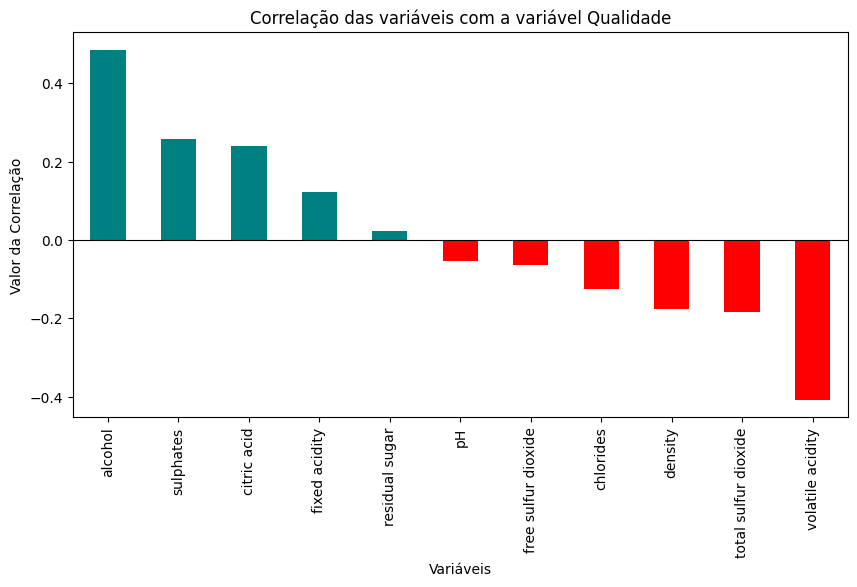

In [54]:
# @title **5.1 Análise de Correlações, Pré-processamento e Modelação**

# Criação de uma copia do Dataframe (df) base para realizar modelações
df_analise = df_wine.copy()

# Remoção de variáveis não quimica como: "Id"
df_analise = df_analise.drop(columns=["Id"], errors="ignore")

# Correlação das variáveis químicas com a variável-alvo "quality" (excluindo a própria).
corr = df_analise.corr()
corr_quality = corr["quality"].drop("quality", errors="ignore").sort_values(ascending=False)

cores = ["red" if valor < 0 else "teal" for valor in corr_quality]

corr_quality.plot(kind="bar", figsize=(10, 5), color=cores)

plt.title("Correlação das variáveis com a variável Qualidade")
plt.ylabel("Valor da Correlação")
plt.xlabel("Variáveis")
plt.axhline(0, color="black", linewidth=0.8)
plt.show()

# Remoção de variáveis não quimica como: "quality"
df_analise = df_analise.drop(columns=["quality"], errors="ignore")

##**Conclusão da Correlação das Variáveis Químicas com a Variável Qualidade**

Com base no gráfico "Correlação das variáveis com a variável qualidade" apresentado, verifica-se que das variáveis utilizadas como hipótese para o estudo ("*alcohol*", "*citric acid*" , "*residual sugar*") apresentam uma correlação positiva com a qualidade, sendo que:
* Álcool apresenta a maior correlação, seguida de "*sulphate*", "*citric acid*" e por último o "*residual sugar*".

Conclui-se que as principais variáveis usadas como hipótese inicial apresentam uma correlação positiva que consolida a estratégia do estudo.

In [55]:
# @title **5.2 Análise da Relação dos Dados com os Valores Discrepantes**
qualidade = df_analise.describe()

lista_resultados = []

# Iterar sobre todas as colunas numéricas para analisar a dispersão dos dados
for coluna in qualidade.columns:

    # Extrair a média e o desvio padrão da tabela de estatísticas descritivas
    media = qualidade.loc["mean", coluna]
    desvio_padrao = qualidade.loc["std", coluna]

# Prevenir erros de divisão por zero caso a média seja exatamente 0
    if media != 0:
      cv = (desvio_padrao / media) * 100 #Coeficiente de Variação em percentagem
      status = "Alto" if cv > 30 else "Baixo"

# Guardar os resultados estruturados na lista "lista_resultados"
      lista_resultados.append({
          "Variáveis": coluna,
          "Desvio Padrão %": cv,
          "Resultado": status
      })

df_resultados_desvio = pd.DataFrame(lista_resultados)
df_desvio_padrao = df_resultados_desvio.sort_values(by="Desvio Padrão %", ascending=False)

#Data Frame relacionada com o Coeficiente de Variação
df_desvio_padrao

,Variáveis,Desvio Padrão %,Resultado
2,citric acid,73.290712,Alto
6,total sulfur dioxide,71.397900,Alto
5,free sulfur dioxide,65.643083,Alto
4,chlorides,54.372376,Alto
3,residual sugar,53.548023,Alto
1,volatile acidity,33.807670,Alto
9,sulphates,25.907967,Baixo
0,fixed acidity,21.027213,Baixo
10,alcohol,10.363762,Baixo
8,pH,4.731602,Baixo


##**Conclusão da Análise de Relação dos Dados com Valores Discrepantes**

A análise da tabela apresentada, revela a alta variabilidade de 6 variáveis químicas com maior volatilidade, em contraste com as 5 variáveis químicas mais estáveis.

Dentro daquilo que são as hipóteses definidas, as variáveis "*citric acid*" e "*residual sugar*", irão ter um impacto significativo na forma como os segmentos variam entre si, enquanto "*alcohol*" terá menor variadade devido à sua estabilidade.








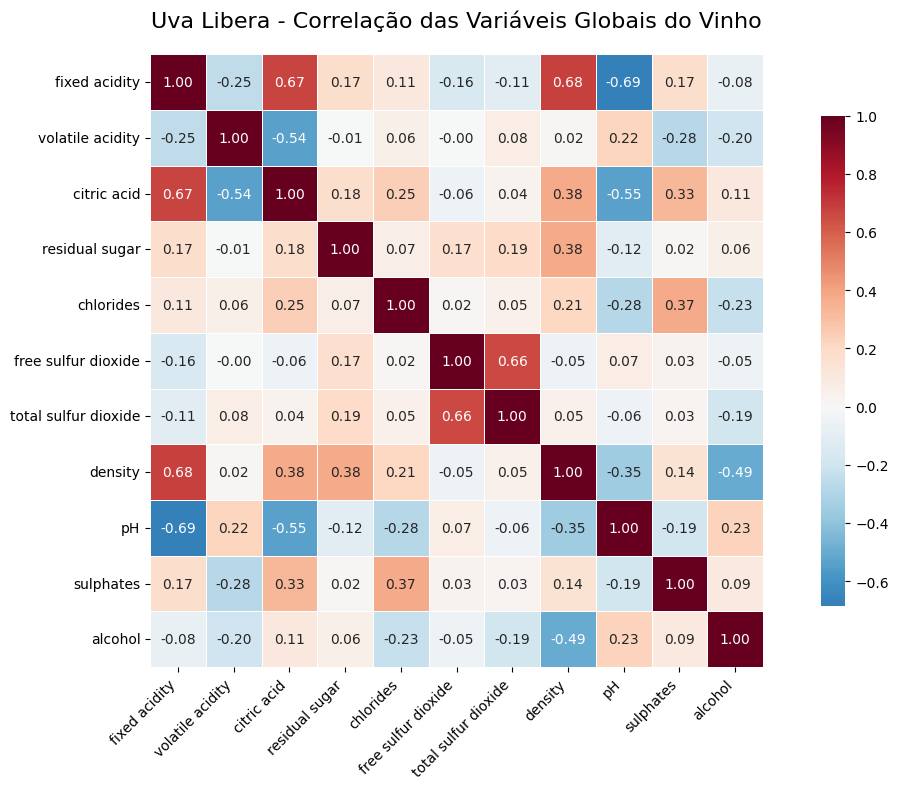

In [56]:
# @title ##**5.3 Correlação das Variáveis - *Heat Map* - "Uva Libera - Correlação das Variáveis Globais do Vinho"**
#Modelagem das Variaveis (Mapa de Calor)

# Heat Map com base nas correspondência entre variáveis.
matriz_correlacao = df_analise.corr()

plt.figure(figsize=(12, 8))

# Configuração do Heat Map
sns.heatmap(
    matriz_correlacao,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    linewidths=0.5,
    linecolor="white",
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title("Uva Libera - Correlação das Variáveis Globais do Vinho", fontsize=16, pad=20)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [57]:
# @title **5.3.1 - Tabela de Ações para as Variáveis**

# Transformar a matriz de correlação (formato grelha) numa tabela.
correlacao_tabela = matriz_correlacao.unstack().reset_index()
correlacao_tabela.columns = ["Variavel 1", "Variavel 2", "Valor Correlacao"]
correlacao_tabela = correlacao_tabela[correlacao_tabela["Variavel 1"] != correlacao_tabela["Variavel 2"]]

# Definição de ação pela % de correlação
def classificar_acao(valor):

    valor_abs = abs(valor)
    if valor_abs > 0.65:
        return "Excluir uma das Variáveis"
    elif valor_abs >= 0.40:
        return "Ponderar uma das Variáveis"
    else:
        return "Assumir ambas Variáveis"

correlacao_tabela["Conclusão da Correlação"] = correlacao_tabela["Valor Correlacao"].apply(classificar_acao)

# Aviso de variáveis a correlacionar por elas mesmas - duplicados.
correlacao_tabela["duplicados"] = correlacao_tabela.apply(
    lambda x: tuple(sorted([x["Variavel 1"], x["Variavel 2"]])),
    axis=1
)
# Eliminação de duplicados
correlacao_tabela = correlacao_tabela.drop_duplicates(subset="duplicados").drop(columns=["duplicados"])

# Ordenar a tabela final pelas correlações mais fortes
top_correlacoes = correlacao_tabela.sort_values(
    by="Valor Correlacao",
    key=lambda x: abs(x),
    ascending=False
)

print("\033[1mTabela de Ações para as Variáveis:\033[0m\n")
(top_correlacoes.head(10))

Tabela de Ações para as Variáveis:



,Variavel 1,Variavel 2,Valor Correlacao,Conclusão da Correlação
8,fixed acidity,pH,-0.685163,Excluir uma das Variáveis
7,fixed acidity,density,0.681501,Excluir uma das Variáveis
2,fixed acidity,citric acid,0.673157,Excluir uma das Variáveis
61,free sulfur dioxide,total sulfur dioxide,0.661093,Excluir uma das Variáveis
30,citric acid,pH,-0.546339,Ponderar uma das Variáveis
13,volatile acidity,citric acid,-0.544187,Ponderar uma das Variáveis
87,density,alcohol,-0.494727,Ponderar uma das Variáveis
40,residual sugar,density,0.380147,Assumir ambas Variáveis
29,citric acid,density,0.375243,Assumir ambas Variáveis
53,chlorides,sulphates,0.374784,Assumir ambas Variáveis


##**Conclusão da Análise das Variáveis com Base no *Heat Map***

Para tornar percetível a correlação entre as variáveis e selecionar aquelas a excluir ou manter no estudo, foi elaborado um *Heatmap* seguido de uma "Tabela de Ações para Variáveis", visando identificar duplicidades e reduzir redundâncias.

Com base no *Heat Map* "Uva Libera - Correlação das Variáveis Globais do Vinho", foram excluídas as seguintes variáveis por redundância ou irrelevância ao estudo:
* "*fixed acidity*" - Redundante;
* "*free sulphul dioxide*" - Redundante;
* "*total sulphur dioxide*" - Sem propósito;
* "*pH*" - Redundante;
* "*chlorides*" - Sem propósito.

A partir deste momento, as variáveis remanescentes revelam-se cruciais para o desenvolvimento da segmentação alinhada ao propósito do projeto.

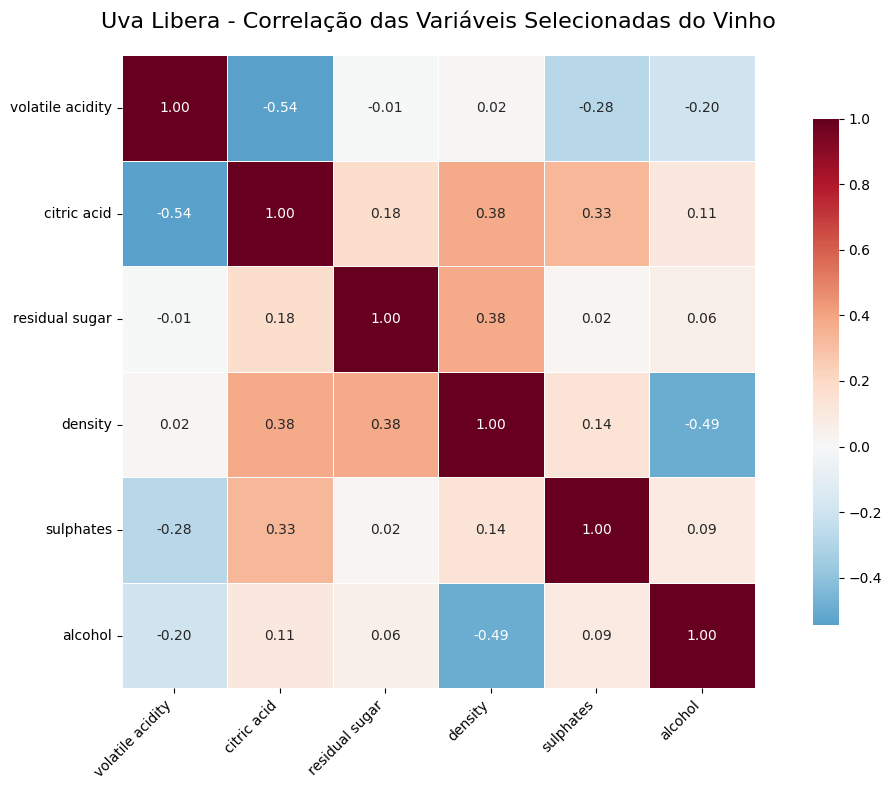

In [58]:
# @title ##**5.3.2 Correlação das Variáveis - *Heat Map* - "Uva Libera - Correlação das Variáveis Selcionadas do Vinho"**

# Variaveis a eliminar
variaveis_libera = df_analise.columns.drop([
  "fixed acidity",
  "free sulfur dioxide",
  "pH",
  "total sulfur dioxide",
  "chlorides"
])

df_libera = df_analise[variaveis_libera]

plt.figure(figsize=(12, 8))

sns.heatmap(
    df_libera.corr(),
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    linewidths=0.5,
    linecolor="white",
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title("Uva Libera - Correlação das Variáveis Selecionadas do Vinho", fontsize=16, pad=20)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

##**Conclusão da análise das variáveis com base no *Heat Map* reduzido**

Nesta fase foi criado o novo *dataset* que usa apenas a variáveis selecionadas:
* "*volatile acidity*" - Indica o potencial de oxidação ou a presença de defeitos sensoriais no vinho.
* "*citric acid*" - Confere frescura e contribui para o perfil aromático e cítrico.
* "*residual sugar*" - Determina o nível de doçura percetível no paladar.
* "*density*" - Reflete a estrutura e o "corpo" do vinho distinguindo perfis mais leves de mais encorpados.
* "*sulphates*" - Contribui para a intensidade do sabor e atua na longevidade do perfil aromático.
* "*Alcohol*" - Contribui para o equiblibrio do vinho com no teor alcólico.


Tendo em conta o propósito do projeto, esta seleção foi conduzida com o objetivo de identificar segmentos de mercado focados na frescura, doçura e perfil gustativo nas suas diferentes vertentes. Por este motivo, considerou-se essencial complementar os atributos de eleição com variáveis estruturais de suporte,nomeadamente a "*density*", os "*sulphates*" e "*volatile acidity*", que enriquecem a caracterização física e sensorial de cada amostra.

Desta forma, toda a exploração e modelação subsequente encontram-se perfeitamente alinhadas com a visão estratégica da marca Uva Libera, garantindo que a análise reflete as características reais que o cliente pretende destacar no seu portefólio.


In [59]:
#Variável de cores usada durante todo o projeto:
cores = ["#264653", "#2a9d8f", "#e76f51", "#f4a261", "#e9c46a", "#8ab17d", "#b5838d"]

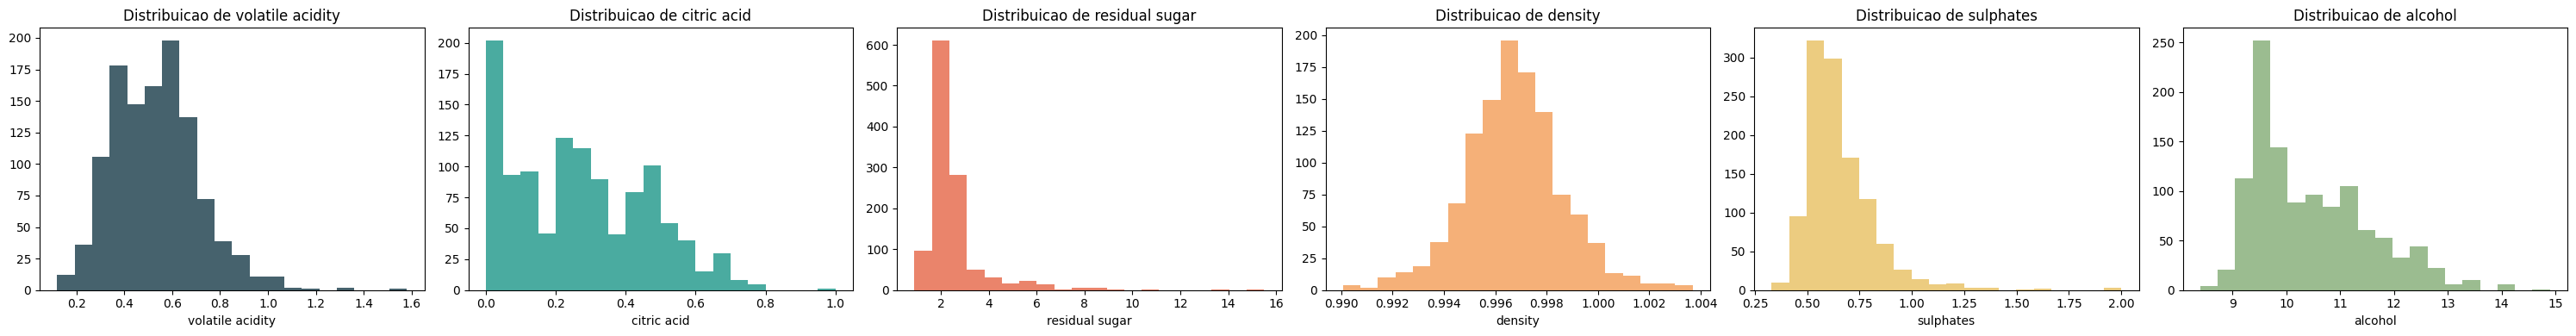

In [60]:
# @title ##**5.4 Análise das Distribuições das Variáveis Selecionadas - Histogramas (toque no Histograma para visualizar)**

colunas_numericas = df_libera.columns

# Contar quantas colunas numéricas existem para saber quantos gráficos vamos precisar
numero_de_graficos = len(colunas_numericas)

# A largura da imagem cresce automaticamente após click na imagem.
fig, axes = plt.subplots(1, numero_de_graficos, figsize=(5 * numero_de_graficos, 4))

# Guarda o numero i da coluna e o seu nome
for i, coluna in enumerate(colunas_numericas):
    # Usar lista global  cores infinitamente, para nunca dar erro de "falta de cor"
    cor = cores[i % len(cores)]

    axes[i].hist(df_analise[coluna], bins=20, color=cor, alpha=0.85)
    axes[i].set_title(f"Distribuicao de {coluna}")
    axes[i].set_xlabel(coluna)

plt.tight_layout()
plt.show()

##**Conclusão da Análise das Distribuições das Variáveis Selecionadas - Histogramas**

A visualização das distribuições através dos histogramas apresentados permite confirmar de forma clara o comportamento dos dados que compõem o estudo:

* Distribuições Normais (em forma de sino): A variável "*density*" apresenta um formato perfeitamente simétrico, o que indica uma grande consistência na estrutura física da maioria dos vinhos da amostra. A "*volatile acidity*" também segue um padrão relativamente centrado.

* Assimetria e Outliers (cauda para a direita): Variáveis como "*residual sugar*", "*sulphates*" e "*alcohol*" não estão centradas. O caso do "*residual sugar*" é o mais evidente: o gráfico comprova que a maioria dos vinhos tem níveis muito baixos de açúcar (concentrados à esquerda), mas a longa cauda que se estende até aos 16 g/l confirma a presença dos valores atípicos (outliers) referidos anteriormente.

* Comportamento Irregular: O "*citric acid*" destaca-se por não seguir uma curva tradicional, apresentando vários picos e uma grande concentração de vinhos com valores exatos ou muito próximos de zero, o que sugere que muitos vinhos da amostra não têm qualquer adição cítrica.

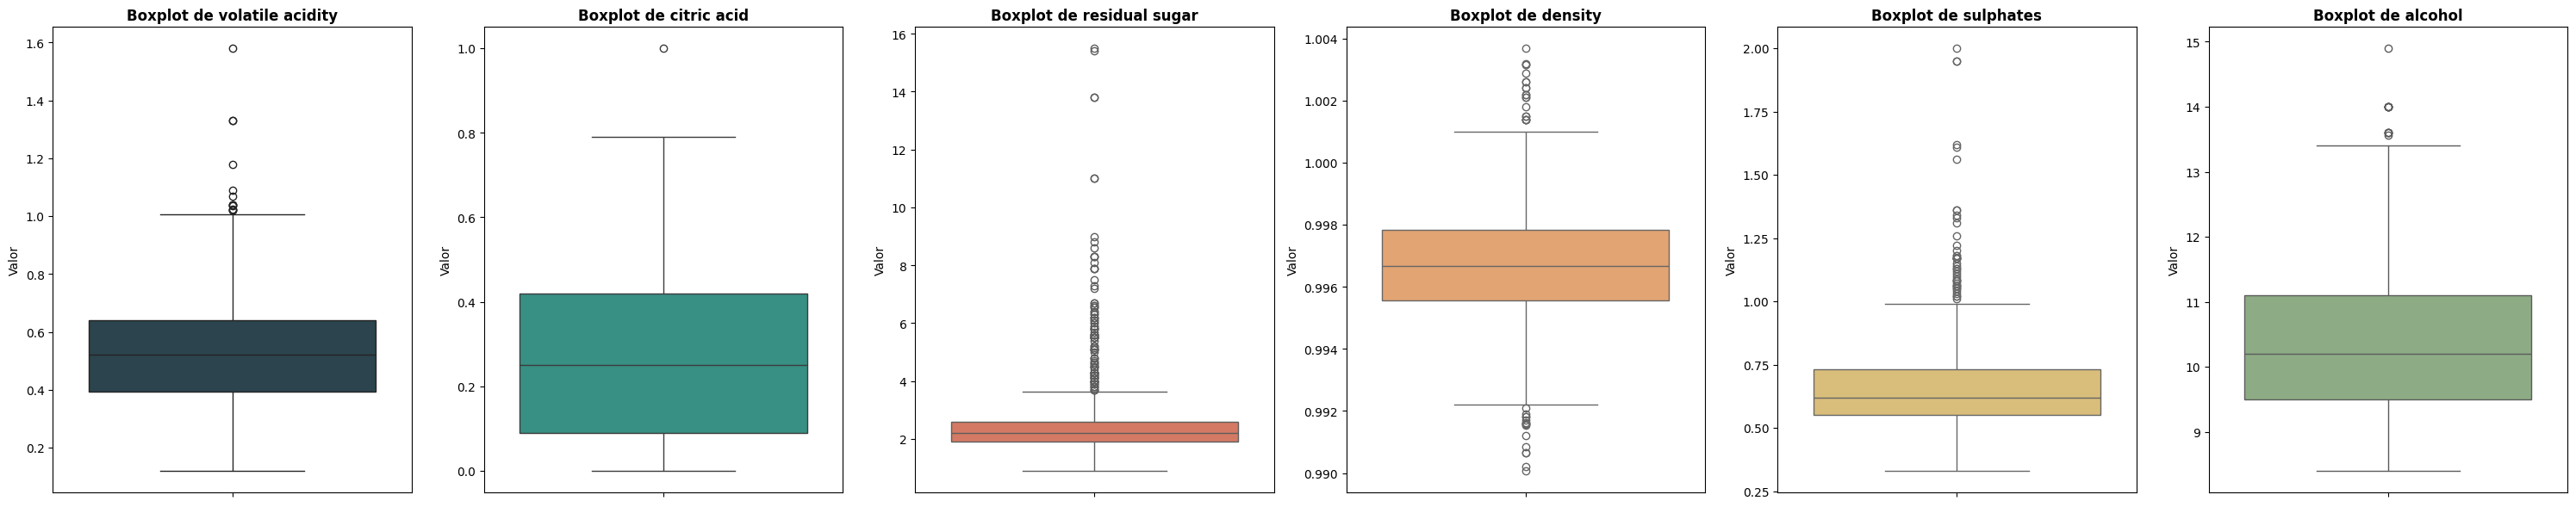

In [61]:
# @title ##**5.5 Análise das Distribuições das Variáveis Selecionadas - *BoxPlots* (toque no Histograma para visualizar)**

# A largura da imagem cresce automaticamente após click na imagem.
fig, axes = plt.subplots(1, numero_de_graficos, figsize=(5 * numero_de_graficos, 6))

# Guarda o numero i da coluna e o seu nome
for i, coluna in enumerate(colunas_numericas):
    cor = cores[i % len(cores)]

    sns.boxplot(data=df_libera, y=coluna, ax=axes[i], color=cor)

    axes[i].set_title(f"Boxplot de {coluna}", fontweight="bold")
    axes[i].set_ylabel("Valor")

plt.tight_layout()
plt.show()


##**Conclusão da Análise das Distribuições das Variáveis Selecionadas - *Boxplots***

A leitura dos *Boxplots* é determinante porque expõe visualmente as diferentes realidades que coabitam no portefólio da Uva Libera, ditando a forma como a análise terá de ser conduzida daqui para a frente:

* A Dualidade do Portefólio: Os gráficos evidenciam a coexistência entre variáveis consistentes e inconsistentes que são determinantes no desenvolvimento de uma base de características quimícas.

* Identificação de Produtos de Nicho: Os valores extremos (outliers, visíveis nos pontos isolados, sobretudo no açúcar residual) não representam erros de produção, mas sim as exceções do portefólio.

O Foco nos próximos passos passa por garantir que o estudo entrega valor real ao negócio, a próxima fase terá de ser capaz de agregar os outliers do "*residual sugar*" que estão relacionados a maiores valores de doçura, com as outras variáveis definidas, principalmente valores acima da média nos "*acid citric*" e valores abaixo da média no "*alcohol*" estes perfis de forma eficaz.

O objetivo do estudo passa agora por isolar estas diferentes realidades, permitindo à Uva Libera definir a sua estratégia.

##**Conclusão da Modelação e Preparação dos dados**

O Capítulo 5 descreve a preparação e afunilamento dos dados, estruturando-se nas seguintes fases:

*   **Análise de Qualidade e Volatilidade:** Avaliação do impacto das
variáveis químicas na qualidade do vinho, com destaque para o residual sugar e o citric acid como principais diferenciadores de segmentos.

*   **Filtro de Correlações:** Eliminação de variáveis redundantes (*fixed acidity, free sulfur dioxide, total sulfur dioxide, pH *e* chlorides*) para otimizar o modelo.

*   **Criação do Novo Dataframe:** Validação das variáveis finais através de um novo Heat Map, garantindo o foco na frescura, doçura e perfil gustativo.

*   **Análise Visual das Distribuições:** Utilização de Histogramas e Boxplots para identificar padrões, outliers e a coexistência de diferentes realidades químicas no portefólio da marca.

Com base nos dados tratados e na modelação preliminar, reconhece-se tratar-se de uma base extensa sujeita a segmentação não supervisionada, cujo objetivo é delinear perfis de vinhos considerando simultaneamente as correlações entre as variáveis selecionadas. Para tal, impõe-se na fase seguinte, a aplicação de um método de Machine Learning adequado a dados limpos e normalizados, capaz de medir distâncias entre amostras. Opta-se assim pelo algoritmo K-means, alinhado com estas necessidades, pois permite avaliar diferentes números de clusters pela sua coesão interna e separação, desvendando padrões ocultos e gerando perfis práticos e interpretáveis de vinhos.

##**6 - Standardizar as Variáveis**

Padronização dos dados de modo a garantir valores estanderizados para o uso do K-means.

---

Esta etapa é essencial para algoritmos sensíveis a distâncias, como o K-means, promovendo uma análise equitativa e resultados mais robustos na identificação de segmentos de vinhos.

In [62]:
# @title **Código para Standardizar Variáveis**
quimicos_means = df_libera.copy()

# Estanderizar as variáveis escolhidas
scaler = StandardScaler()
quimicos_means_scaled = scaler.fit_transform(quimicos_means)

df_libera_means = pd.DataFrame(quimicos_means_scaled, columns=quimicos_means.columns)

print("Media apos standardizacao (aprox. 0):")
print(df_libera_means.mean().round(4))

print("\nDesvio padrao apos standardizacao (aprox. 1):")
print(df_libera_means.std(ddof=0).round(4))


Media apos standardizacao (aprox. 0):
volatile acidity    0.0
citric acid         0.0
residual sugar      0.0
density             0.0
sulphates           0.0
alcohol            -0.0
dtype: float64

Desvio padrao apos standardizacao (aprox. 1):
volatile acidity    1.0
citric acid         1.0
residual sugar      1.0
density             1.0
sulphates           1.0
alcohol             1.0
dtype: float64


##**Conclusão para a Standarização das Variáveis** #Remover

A padronização das variáveis remanescentes transforma os dados em valores com média zero e desvio padrão unitário, equalizando o seu contributo no cálculo de distâncias euclidianas.

Este procedimento prepara adequadamente o *dataframe* para a aplicação do *K-means*, minimizando distorções e maximizando a identificação de segmentos de mercado distintos, permitindo à Uva Libera direcionar estratégias comerciais precisas, como posicionamento de produtos por perfis de frescura, doçura ou intensidade gustativa, e maximizar oportunidades de valorização e vendas.

##**7 - Regra do Cotovelo + Coeficiente Sillhouette**

Para uma análise dos possíveis segmentos, aplicou-se a "Regra do Cotovelo" e o "Coeficiente Sillhouette" que norteão o número de clusters necessários para o propósito.

É com base nessa análise que se concluirá a formula química mencionada ao longo do estudo.


In [63]:
# @title **Código para Regra do Cotovelo + Coeficiente Silhouette**

# Definir o limite máximo de clusters a testar (por defeito, o número de colunas + 1)
max_variaveis = len(df_libera_means.columns) + 1

def calcular_metricas_k(df_k, lista_variaveis, k_min=2, k_max=max_variaveis):
    valor = df_k[lista_variaveis].copy()

    scaler_metricas = StandardScaler()
    valor_scaled = scaler_metricas.fit_transform(valor)

    # Listas vazias para ir guardando os resultados de cada teste
    resultados_k = []
    inercia_anterior = None # Variável auxiliar para calcular a quebra de percentagem no "Cotovelo"

    for k in range(k_min, k_max + 1):
        modelo = KMeans(n_clusters=k, init="k-means++", random_state=42, n_init=20)

        # Treinar o modelo e atribuir cada vinho ao seu respetivo cluster
        labels = modelo.fit_predict(valor_scaled)
        # Inércia: mede o quão "apertados" ou próximos os dados estão dentro do seu próprio cluster
        inercia_atual = modelo.inertia_

        if inercia_anterior is not None:
            mudanca = ((inercia_atual - inercia_anterior) / inercia_anterior) * 100
        else:
            mudanca = 0

        # Guardar as métricas para este número de clusters (k)
        resultados_k.append({
            "k": k,
            "inercia": inercia_atual,
            # Guardar as métricas para este número de clusters (k)
            "silhouette": silhouette_score(valor_scaled, labels),
            "mudança_%": mudanca
        })

        inercia_anterior = inercia_atual

    return pd.DataFrame(resultados_k)

# Aplicar a função a todas as variáveis do dataset da Uva Libera
componentes_variaveis = df_libera.columns.tolist()
metricas_base = calcular_metricas_k(df_k=df_libera, lista_variaveis=componentes_variaveis)
metricas_base.round(2)

,k,inercia,silhouette,mudança_%
0,2,5281.91,0.25,0.00
1,3,4395.69,0.26,-16.78
2,4,3794.91,0.26,-13.67
3,5,3396.79,0.25,-10.49
4,6,3089.34,0.24,-9.05
5,7,2841.85,0.21,-8.01


In [64]:
# @title **Código para a Formação do Gráfico Conjunto**

# varia apenas entre -1 e 1. De modo a visualizar ambos os testes
fig_metricas = make_subplots(specs=[[{"secondary_y": True}]])

fig_metricas.add_trace(
    go.Scatter(x=metricas_base["k"], y=metricas_base["inercia"], mode="lines+markers", name="Inercia"),
    secondary_y=False,
)
fig_metricas.add_trace(
    go.Scatter(x=metricas_base["k"], y=metricas_base["silhouette"], mode="lines+markers", name="Silhouette"),
    secondary_y=True,
)

fig_metricas.update_layout(
    title="Regra do cotovelo + Silhouette (base)",
    template="plotly_white",
    xaxis_title="Numero de clusters (k)",
)
fig_metricas.update_yaxes(title_text="Inercia", secondary_y=False)
fig_metricas.update_yaxes(title_text="Silhouette", secondary_y=True)
fig_metricas.show()


##**Conclusão para a Regra do Cotovelo + Coeficiente *Sillhouette***
Com base no gráfico, conclui-se que a amostra deve ser dividida em 4 clusters. Este é o número ideal para identificar segmentos distintos que representem, de forma fiel, as várias preferências do mercado.


##**8 - Escolha do Número de Clusters Através do Algoritmo *K-means***
O objetivo consiste em testar diferentes valores de k - indicador de n.º clusters - sobre o dataframe padronizado, avaliando simultaneamente a qualidade da segmentação obtida e a sua relevância para o negócio do vinho.

Desta forma, a seleção do número final de clusters deixa de ser apenas um exercício estatístico e passa a refletir também a interpretabilidade dos grupos e o seu potencial para suportar decisões estratégicas de posicionamento e oferta de produto.

In [65]:
# @title Função - Gráfico Radar (Adicional)
def plot_radares_clusters(tabela_final, colunas_radar, titulo_base="Perfil dos Clusters"):

    # 1. Preparação das categorias (substitui espaços por quebras de linha para não sobrepor o gráfico)
    categorias_grafico = [c.replace(' ', '\n') for c in colunas_radar]
    num_vars = len(categorias_grafico)
    k_clusters = len(tabela_final)

    # Fechar o círculo (ângulos)
    angulos = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angulos += angulos[:1]

    # 2. Configurar a moldura dos subplots
    fig, axes = plt.subplots(1, k_clusters, figsize=(6 * k_clusters, 6), subplot_kw=dict(polar=True))

    # 3. Loop de desenho
    for i in range(k_clusters):

        # Pegar os valores e fechar o círculo
        valores = tabela_final.loc[i, colunas_radar].values.tolist()
        valores += valores[:1]
        ax = axes[i]
        cor = cores[i % len(cores)]

        # Desenhar linha e preenchimento
        ax.plot(angulos, valores, color=cor, linewidth=2)
        ax.fill(angulos, valores, color=cor, alpha=0.3)

        # Configurar rótulos das variáveis
        ax.set_xticks(angulos[:-1])
        ax.set_xticklabels(categorias_grafico, fontsize=10)
        ax.tick_params(axis='x', pad=20)

        # Escala: definida pelos limites dos dados + espaço para o texto
        v_min = tabela_final[colunas_radar].min().min() - 0.8
        v_max = tabela_final[colunas_radar].max().max() + 0.8
        ax.set_ylim(v_min, v_max)

        # Linha da Média (Z-score = 0)
        ax.plot(angulos, [0]*len(valores), color='grey', linestyle='--', linewidth=1, alpha=0.5)

        # Título do gráfico individual
        n_amostras = tabela_final.loc[i, 'Amostras']
        ax.set_title(f"Cluster {i}\n({int(n_amostras)} vinhos)", size=14, color=cor, pad=50)

    plt.tight_layout(pad=4.0)
    plt.show()

# **Nota prática para execução do Notebook:** **Introduzir K=4 no próximo passo**

Introduz o número de valores k,
4

Perfilamento com 6 variáveis:


,volatile acidity,citric acid,residual sugar,density,sulphates,alcohol,Amostras
Cluster,,,,,,,
0,0.671,-0.728,-0.189,-0.073,-0.432,-0.404,528
1,-0.600,0.929,-0.159,0.685,0.544,-0.375,321
2,-0.676,0.152,-0.250,-1.165,0.169,1.340,227
3,-0.121,0.772,3.100,1.235,0.219,0.437,67


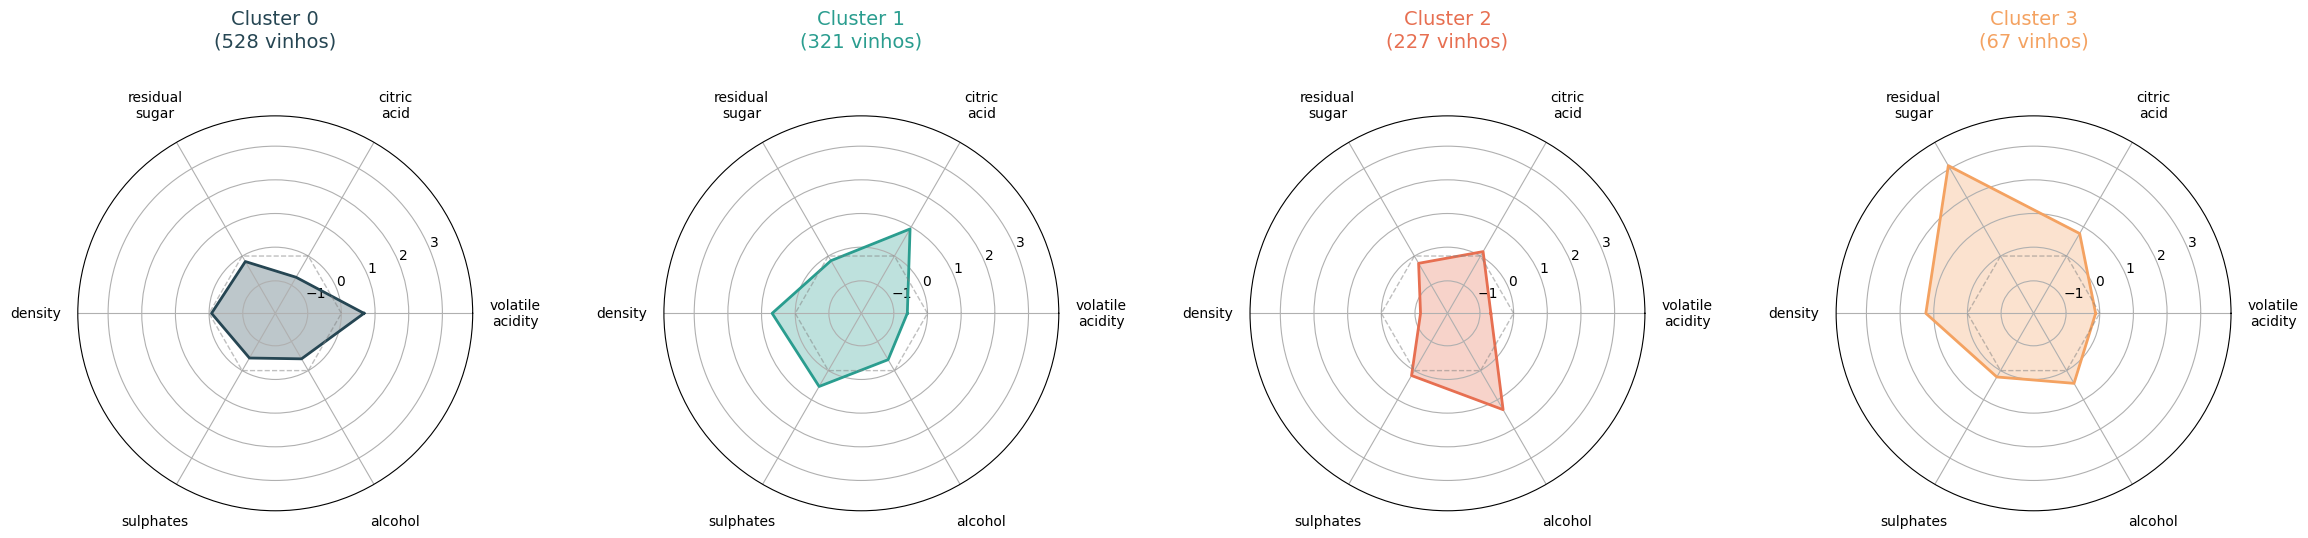

In [66]:
# @title **8.1 - Aplicação *K-means* em que K = 4**

# Liberdade de pesquisa dos clusters, neste o estudo usou-se 4.
print("Introduz o número de valores k,")
numero_de_clusters = int(input())

variaveis_escolhidas = df_libera_means.columns.tolist()

# Assume o número k definido pelo utilizador
k_final = numero_de_clusters
modelo = KMeans(n_clusters=k_final, init="k-means++", random_state=42, n_init=20)

clusters = modelo.fit_predict(df_libera_means[variaveis_escolhidas])

tabela_perfil = df_libera_means[variaveis_escolhidas].copy()
tabela_perfil['Cluster'] = clusters

# Isto cria o "Bilhete de Identidade" de cada grupo (ex: qual é a média de açúcar ou de álcool do Cluster 1?)
tabela_final = tabela_perfil.groupby('Cluster').mean()
# Contar quantos vinhos caíram em cada grupo para percebermos o peso comercial (volume) de cada segmento
tabela_final['Amostras'] = tabela_perfil.groupby('Cluster').size()

print(f"\nPerfilamento com {len(variaveis_escolhidas)} variáveis:")

# Mostrar a tabela ordenada pelos clusters com mais vinhos (do maior para o mais de nicho)
display(tabela_final.sort_values(by='Amostras', ascending=False).round(3))
print("\n\n")

# Chamar a função visual que transforma esta tabela de médias num gráfico de radar
plot_radares_clusters(tabela_final, variaveis_escolhidas)

##**Conclusão da Aplicação **K-means** em que k = 4**

A execução do K-means admitindo "k"=4 confirma a hipótese demonstrada acerca da existência de um vinho com componentes quimícas que apresentam valores acima da média de açúcar e ácido citríco, com baixo teor de álcool - denominado por **"Cluster 3"**.

Contudo, a análise revela que este apresenta amostras excessivamente reduzidas (67), limitando a sua representatividade prática e viabilidade comercial.

Esta observação motiva a diminuição de n.º "k" para 3, refinando a segmentação para perfis mais equilibrados e estratégicos, alinhados com nichos de mercado reais, e excluindo a possibilidade da criação de um segmento beaseado em possíveis outliers e com pouca expressão e impacto no negócio devido a uma quantidade da amostra bastante reduzida.

#**Nota prática para execução do Notebook:** **Introduzir K=3 no próximo passo**

Introduz o número de valores k,
3

Perfilamento com 6 variáveis:


,volatile acidity,citric acid,residual sugar,density,sulphates,alcohol,Amostras
Cluster,,,,,,,
2,0.618,-0.690,-0.161,-0.051,-0.417,-0.433,563
1,-0.528,1.023,0.367,0.907,0.588,-0.239,333
0,-0.698,0.193,-0.128,-1.107,0.158,1.309,247


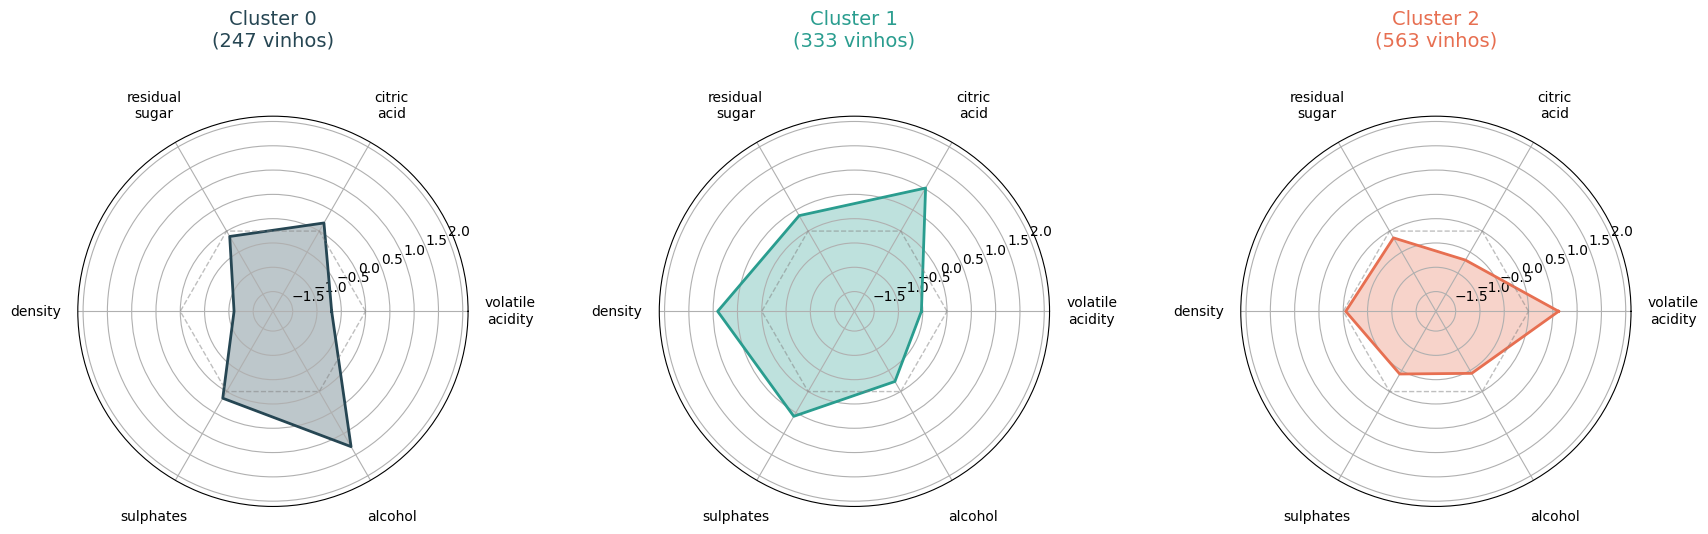

In [67]:
# @title **8.2 - Aplicação *K-means* em que K = 3**
print("Introduz o número de valores k,")
numero_de_clusters = int(input())

# Liberdade de pesquisa dos clusters, neste o estudo usou 3.
variaveis_escolhidas = df_libera_means.columns.tolist()

# Assume o número k definido pelo utilizador
k_final = numero_de_clusters
modelo = KMeans(n_clusters=k_final, init="k-means++", random_state=42, n_init=20)

clusters = modelo.fit_predict(df_libera_means[variaveis_escolhidas])

tabela_perfil = df_libera_means[variaveis_escolhidas].copy()
tabela_perfil['Cluster'] = clusters

# Isto cria o "Bilhete de Identidade" de cada grupo (ex: qual é a média de açúcar ou de álcool do Cluster 1?)
tabela_final = tabela_perfil.groupby('Cluster').mean()
# Contar quantos vinhos caíram em cada grupo para percebermos o peso comercial (volume) de cada segmento.
tabela_final['Amostras'] = tabela_perfil.groupby('Cluster').size()

print(f"\nPerfilamento com {len(variaveis_escolhidas)} variáveis:")

# Mostrar a tabela ordenada pelos clusters com mais vinhos (do maior para o mais de nicho)
display(tabela_final.sort_values(by='Amostras', ascending=False).round(3))
print("\n\n")

# Chamar a função visual que transforma esta tabela de médias num gráfico de radar
plot_radares_clusters(tabela_final, variaveis_escolhidas)

In [68]:
# @title **8.3 - Criação Gráfico Clusters *K-means* em 3D**
variaveis_3d = ["alcohol", "citric acid", "residual sugar"]
df_plot = df_libera_means[variaveis_3d].copy()
df_plot["Cluster"] = clusters.astype(str)

# 3. Os centroides
centroides = tabela_final[variaveis_3d]

# 4. Criar o gráfico Scatter 3D com as tuas CORES
fig_3d = px.scatter_3d(
    df_plot,
    x=variaveis_3d[0],
    y=variaveis_3d[1],
    z=variaveis_3d[2],
    color="Cluster",
    opacity=0.60,
    # Mapeia os clusters para as tuas cores específicas
    color_discrete_sequence=cores,
    category_orders={"Cluster": ["0", "1", "2"]}
)

fig_3d.update_traces(
    marker=dict(
        size=3,
        line=dict(width=0)
    ),
    selector=dict(mode='markers')
)

# 5. Adicionar os Centroides
fig_3d.add_trace(
    go.Scatter3d(
        x=centroides[variaveis_3d[0]],
        y=centroides[variaveis_3d[1]],
        z=centroides[variaveis_3d[2]],
        mode="markers+text",
        name="Centroides",
        text=[f"C{i}" for i in centroides.index],
        textposition="top center",
        marker=dict(
            size=4,
            color="black",
            symbol="diamond",
            opacity=1,
            line=dict(width=2, color="white")
        ),
    )
)

# 6. Melhorar o layout e centralização
fig_3d.update_layout(
    autosize=False,
    width=1000,
    height=500,
    margin=dict(l=0, r=0, b=0, t=50),
    title={
        'text': f"Clusters K-Means em 3D (k={k_final})",
        'y': 0.95,
        'x': 0.5,
        'xanchor': 'center',
        'yanchor': 'top',
        'font': {'size': 20}
    },
    legend=dict(
        title="Clusters",
        orientation="h",
        yanchor="bottom",
        y=0.02,
        xanchor="center",
        x=0.5
    ),
    scene=dict(
        xaxis_title="alcohol",
        yaxis_title="citric acid",
        zaxis_title="residual sugar"
    )
)

fig_3d.show()

##**Conclusão da Aplicação *K-means* em que K = 3**
Posteriormente, procede-se a uma avaliação iterativa, ajustando k para alinhar os clusters com os objetivos estratégicos do projeto.

A diminuição do *K-means* para "k"=3 produz perfis equilibrados e interpretáveis, superando as limitações feitas na análise anterior, ao eliminar grupos minoritários e continuando a alinhar-se com a Regra do Cotovelo e *Silhouette*.

O "Cluster 1" destaca-se como ideal para o negócio, caracterizado por elevada frescura ("*citric acid elevado*"), doçura acima da média ("*residual sugar*") e baixo teor alcoólico, posicionando-o como um produto que vá ao encontro da procura feita pela empresa.

Esta configuração final otimiza o portefólio de vinhos da Uva Libera e identifica o segmento ideal para o propósito do projeto.

##**9 - Conclusão Final**

Este estudo constitui uma contribuição importante ao campo da análise de dados em vinho, demonstrando de forma empírica como o algoritmo *K-means*, aplicado a dados analisados e modelados com rigor, transcende limitações inerentes a *datasets* heterogéneos para gerar *insights* estratégicos de elevado valor.

A trajetória metodológica, desde a caracterização inicial e a eliminação de variáveis redundantes no capítulo 4, passando pela normalização escalar no Ponto 5, determinação ótima de k no Ponto 6, até à validação iterativa entre k=4 e k=3, exemplifica um paradigma de *data science* responsável, onde critérios estatísticos entrelaçam-se com juízos de utilidade prática.

Partindo de dados químicos variados e por vezes confusos, o trabalho chega a três *clusters* claros e úteis, resolvendo problemas como segmentos desequilibrados no teste com 4 *clusters* e escolhendo o melhor número de clusters.

Concluindo, com base na base de dados entregue pelo cliente, apresentam-se três clusters finais que conectam diretamente ao negócio:

*   Cluster 0 (Perfil seco, alcoólico e estruturado): Caracteriza-se por níveis elevados de álcool e baixa densidade. É o segmento direcionado aos consumidores que valorizam vinhos fortes e de perfil mais tradicional.
*   Cluster 2 (Perfil leve e simples): Apresenta um perfil globalmente equilibrado, nomeadamente ao nível da acidez. Funciona como a aposta segura para agradar ao público em geral e garantir volume comercial.
*   **Cluster 1 (O "Perfil fresco e ácido"):** Destaca-se pela sua frescura elevada, doçura moderada e baixo teor alcoólico. É o produto ideal para captar o segmento mais jovem e responder à tendência crescente, e altamente rentável, do consumo de vinhos mais leves.

**Sugestões:**

Os resultados desta segmentação entregam à administração ferramentas reais e acionáveis para otimizar o negócio em quatro frentes:

* **Otimização do Portefólio:** Simplificar a oferta para facilitar a decisão de compra do consumidor, eliminando redundâncias na prateleira.

* **Marketing e Preço Direcionados:** Ajustar a estratégia de pricing ao perfil de cada segmento e rentabilizar o investimento publicitário através de campanhas nas redes sociais feitas à medida do público-alvo.

* **Inovação Guiada por Dados:** Reduzir o risco financeiro no lançamento de novos produtos, utilizando o perfil do nosso segmento estrela como "receita" para as próximas colheitas.

+ **Eficiência e Rentabilidade:** Ao alinhar a produção com a procura real, direcionando as vendas para os clientes certos e reduzindo o stock de produtos parados, a marca posiciona-se para ganhos significativos de margem - estudos em retalho apontam que abordagens guiadas por clusters podem impulsionar os lucros em até 20%.

O estudo culmina exatamente na identificação clara e fundamentada do vinho ideal para o que foi definido para os jovens, garantindo à Uva Libera o produto certo para renovar a sua base de clientes e impulsionar o seu crescimento.